# Dengue formulation lab

Four formulations, fitted and scored on the past. Everything analytical is
imported from `lib/`; what you edit is section 2.

| | incidence | mortality / CFR | year term | rake |
|---|---|---|---|---|
| **F1** | base cell (age 3 / sex 1) | CFR across all age/sex, with `as_id` | year x SR linear | median 2014-2023 |
| **F2** | all-age, uses mortality | mortality all-age | year x SR linear | mean 2014-2023, LOO outliers |
| **F3** | = F1 | = F1 | year x SR **spline** | = F1 |
| **F4** | = F2 | = F2 | year x SR **spline** | = F2 |

Metrics are reported **raked and unraked**, in **natural and model space**.


## 1. Inputs

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.lib.data.dengue_inputs import load_dengue_inputs
from idd_forecast_mbp.lib.modeling import specs as specs_mod
from idd_forecast_mbp.lib.modeling.anchor import AnchorSpec, Baseline, Eligibility
from idd_forecast_mbp.lib.modeling.dengue_formulations import (
    CFR, INCIDENCE, MORTALITY, Formulation,
)
from idd_forecast_mbp.lib.modeling.dengue_pipeline import run_formulations
from idd_forecast_mbp.lib.processing.dengue_products import (
    MEASURES, build_hierarchy_products,
)

ANCHOR_YEAR = 2023
WINDOW = tuple(range(2014, 2024))   # 2014-2023

inputs = load_dengue_inputs(grain='fhs', anchor_year=ANCHOR_YEAR)
H = inputs.hierarchy.set_index('location_id')
LEVEL, NAME = H['level'], H['location_name']
AS_POP = inputs.fit_frame[['location_id','year_id','age_group_id','sex_id','population']]

# Super-region masked year columns. Only 6 super-regions have any dengue fit
# location -- SR 31 (Central Europe/Eastern Europe/Central Asia) has zero observed
# dengue, so it never enters and is excluded from the plots too.
#
# YEAR IS CENTRED BEFORE MASKING. This is not cosmetic. Masking raw year_id to 0
# outside a super-region makes the column ~= 2000 * [in that SR] plus 23 units of
# actual year variation, so it is 99% an INDICATOR of the super-region -- which is
# collinear with the A0_af country factor. The coefficient then absorbs a level
# offset instead of a slope, and all six come out at the same value regardless of
# the data. Uncentred, the six fitted mortality slopes were +0.0245..+0.0282 while
# observed ranged -0.003..+0.072 (SEA has FALLING dengue mortality and was fitted
# at +0.027). Centring puts the out-of-group zero at the in-group mean year, so the
# level component vanishes and the slope is identified from within-group variation
# only. Correlation with the observed super-region slopes: +0.26 -> +0.95.
YEAR_CENTER = float(inputs.fit_frame['year_id'].mean())
# Unmasked centred year, for the per-super-region fits: inside a single
# super-region there is nothing to mask, so a spline on this column is clean.
inputs.fit_frame['year_centered'] = inputs.fit_frame['year_id'] - YEAR_CENTER
SUPER_REGIONS = sorted(inputs.fit_frame['super_region_location_id'].unique())
YEAR_SR_COLS = []
for sr in SUPER_REGIONS:
    c = f'year_sr_{int(sr)}'
    inputs.fit_frame[c] = np.where(
        inputs.fit_frame['super_region_location_id'] == sr,
        inputs.fit_frame['year_id'] - YEAR_CENTER, 0.0)
    YEAR_SR_COLS.append(c)
# Super-region factor, for trying SR intercepts instead of country intercepts.
# Not the default: it scores far worse (pseudo-R2 0.54 vs 0.92, AIC +12,668) and
# recovers the slopes no better, because country intercepts are nested inside SR.
inputs.fit_frame['sr_af'] = (inputs.fit_frame['super_region_location_id']
                             .astype('category').cat.codes.astype('int64'))

print(f"{len(inputs.fit_frame):,} rows | {inputs.fit_frame.location_id.nunique()} locations"
      f" | {inputs.fit_frame.year_id.min()}-{inputs.fit_frame.year_id.max()}")
print('super-regions:', [f'{int(s)} ({NAME[s]})' for s in SUPER_REGIONS])

366,000 rows | 305 locations | 2000-2023
super-regions: ['4 (Southeast Asia, East Asia, and Oceania)', '64 (High-income)', '103 (Latin America and Caribbean)', '137 (North Africa and Middle East)', '158 (South Asia)', '166 (Sub-Saharan Africa)']


### Covariate menu

Everything on the fit frame you can put in a term. Forms: `linear`, `mpi`
(monotone-increasing spline, takes a `k`), `s` (unconstrained spline), `factor`.

In [2]:
skip = {'location_id','year_id','age_group_id','sex_id','fhs_location_id','level',
        'most_detailed_lsae','most_detailed_fhs','most_detailed_gbd','population'}
avail = [c for c in sorted(inputs.fit_frame.columns)
         if c not in skip and not c.startswith('year_sr_')]
print('\n'.join(f'  {c}' for c in avail))

  A0_af
  A0_location_id
  as_id
  days_over_30C
  dengue_cfr
  dengue_inc_rate
  dengue_mort_rate
  dengue_suitability
  gdppc_mean
  ldipc_mean
  log_dengue_inc_rate
  log_dengue_mort_rate
  log_gdppc_mean
  logit_dengue_cfr
  logit_urban_fraction
  mean_high_temperature
  mean_low_temperature
  mean_temperature
  people_flood_days
  people_flood_days_per_capita
  precipitation_days
  region_location_id
  relative_humidity
  rr_inc_as
  sr_af
  super_region_location_id
  total_precipitation
  urban_fraction
  weighted_100m_urban_threshold_1500.0_simple_mean
  weighted_100m_urban_threshold_300.0_simple_mean
  weighted_1km_urban_threshold_1500.0_simple_mean
  weighted_1km_urban_threshold_300.0_simple_mean
  wind_speed
  year_centered


## 2. Formulations — **edit here**

In [11]:
# Anchors ----------------------------------------------------------------------
RAKE_2023 = AnchorSpec.point(2023)
RAKE_MEDIAN = AnchorSpec(years=WINDOW, baseline=Baseline(statistic='median'))
RAKE_MEAN_LOO = AnchorSpec(
    years=WINDOW, baseline=Baseline(statistic='mean'),
    eligibility=Eligibility(method='mean', threshold_sd=10.0, direction='both'))

# year x super-region: one masked column per super-region (year where in that SR,
# 0 elsewhere). Built in section 1 because the column names depend on the data.
YEAR_SR_LIN = tuple(specs_mod.Term(c, 'linear') for c in YEAR_SR_COLS)
YEAR_SR_SPL = tuple(specs_mod.Term(c, 'smooth', 5) for c in YEAR_SR_COLS)

T = specs_mod.Term   # every model below is written out in full; edit in place

# ------------------------------------------------------------------ F1 --------
# THE 2025 RUN. Verbatim from 03_modeling/final_models_dengue.r:
#   mod_inc_base: suitability + relative_humidity + logit_urban + flood_days + A0
#   mod_cfr_all:  log_gdppc + as_id + A0
# All linear (the scam monotone variants were commented out) and NO year term.
# Given the same rake as the others so the only difference is the regression.
F1 = Formulation(
    id='2025_run',
    description='the 2025 run: no year term',
    structure='inc_cfr',
    terms={
        INCIDENCE: (T('dengue_suitability',           'mpi', 6),
                    T('logit_urban_fraction',         'linear'),
                    T('A0_af', 'factor')),
        CFR:       (T('log_gdppc_mean', 'linear'),
                    T('as_id',  'factor'),
                    T('A0_af',  'factor')),
    },
    response_grain={CFR: 'age_sex'},
    anchor=RAKE_2023,
    anchor_group=('location_id', 'age_group_id', 'sex_id'),
    year_term=None,
)

# ------------------------------------------------------------------ F2 --------
F2 = Formulation(
    id='2025_run_w_time',
    description='the 2025 run: with year term',
    structure='inc_cfr',
    terms={
        INCIDENCE: (*YEAR_SR_LIN,
                    T('dengue_suitability',           'mpi', 6),
                    T('logit_urban_fraction',         'linear'),
                    T('A0_af', 'factor')),
        CFR:       (T('log_gdppc_mean', 'linear'),
                    T('as_id',  'factor'),
                    T('A0_af',  'factor')),
    },
    response_grain={CFR: 'age_sex'},
    anchor=RAKE_MEDIAN,
    anchor_group=('location_id', 'age_group_id', 'sex_id'),
    year_term=None,
)

F3 = Formulation(
    id='2025_run_w_time_spl',
    description='as F2, fitted per super-region with a centred year spline',
    structure='inc_cfr',
    terms={
        INCIDENCE: (T('year_centered',      'smooth', 5),
                    T('dengue_suitability', 'mpi', 6),
                    T('urban_fraction',     'linear'),
                    T('A0_af', 'factor')),
        CFR:       (T('log_gdppc_mean', 'linear'),
                    T('A0_af', 'factor'),
                    T('as_id',  'factor')),
    },
    response_grain={CFR: 'age_sex'},
    anchor=RAKE_MEDIAN,
    anchor_group=('location_id', 'age_group_id', 'sex_id'),
    year_term='by_super_region',
    by_super_region=True,
)


# ------------------------------------------------------------------ F3 --------
F4 = Formulation(
    id='GBD-esque_w_time',
    description='mortality then incidence, both all-age; incidence uses mortality',
    structure='mort_then_inc',
    terms={
        MORTALITY: (*YEAR_SR_LIN,
                    T('dengue_suitability',  'mpi', 6),
                    T('log_gdppc_mean',      'linear'),
                    T('urban_fraction',      'linear'),
                    T('relative_humidity',  'mpi', 6),
                    T('A0_af', 'factor')),
        INCIDENCE: (T('log_dengue_mort_rate', 'linear'),   # observed at fit,
                    *YEAR_SR_LIN,                          # predicted at predict
                    T('log_gdppc_mean',     'linear'),
                    T('dengue_suitability', 'mpi', 6),
                    T('urban_fraction',     'mpi', 6),
                    T('relative_humidity',  'mpi', 6),
                    T('A0_af', 'factor')),
    },
    response_grain={MORTALITY: 'all_age', INCIDENCE: 'all_age'},
    anchor=RAKE_MEAN_LOO,
    anchor_group=('location_id',),
    year_term='linear',
)

F5 = Formulation(
    id='GBD-esque_w_time_spl',
    description='as F4, fitted per super-region with a centred year spline',
    structure='mort_then_inc',
    terms={
        MORTALITY: (T('year_centered',       'smooth', 5),
                    T('dengue_suitability',  'mpi', 6),
                    T('log_gdppc_mean',      'linear'),
                    T('urban_fraction',      'linear'),
                    T('relative_humidity', 'mpi', 6),
                    T('A0_af', 'factor')),
        INCIDENCE: (T('log_dengue_mort_rate', 'linear'),
                    T('year_centered',        'smooth', 5),
                    T('log_gdppc_mean',       'linear'),
                    T('dengue_suitability',   'mpi', 6),
                    T('urban_fraction',       'mpi', 6),
                    T('relative_humidity',    'mpi', 6),
                    T('A0_af', 'factor')),
    },
    response_grain={MORTALITY: 'all_age', INCIDENCE: 'all_age'},
    anchor=RAKE_MEAN_LOO,
    anchor_group=('location_id',),
    year_term='by_super_region',
    by_super_region=True,
)



FORMULATIONS = [F1, F2, F3, F4, F5]
for f in FORMULATIONS:
    print(f'{f.id:22s} {f.structure:14s} rake={f.anchor.baseline.statistic:6s} '
          f'by_sr={str(f.by_super_region):5s} '
          f'grains={ {o: f.grain_for(o) for o in f.fitted_outcomes} }')


2025_run               inc_cfr        rake=single by_sr=False grains={'incidence': 'base_cell', 'cfr': 'age_sex'}
2025_run_w_time        inc_cfr        rake=median by_sr=False grains={'incidence': 'base_cell', 'cfr': 'age_sex'}
2025_run_w_time_spl    inc_cfr        rake=median by_sr=True  grains={'incidence': 'base_cell', 'cfr': 'age_sex'}
GBD-esque_w_time       mort_then_inc  rake=mean   by_sr=False grains={'mortality': 'all_age', 'incidence': 'all_age'}
GBD-esque_w_time_spl   mort_then_inc  rake=mean   by_sr=True  grains={'mortality': 'all_age', 'incidence': 'all_age'}


## 3. Run — raked and unraked

Unraked is the same formulation with `anchor=None`: the model's own level stands,
which shows how much of the fit the rake is doing versus the covariates.

In [12]:
from dataclasses import replace

VARIANTS = {'raked': FORMULATIONS,
            'unraked': [replace(f, id=f.id + '_unraked', anchor=None)
                        for f in FORMULATIONS]}

results = {}
for kind, fs in VARIANTS.items():
    runs = run_formulations(inputs, fs, n_jobs=min(8, len(fs)), backend='loky')
    for name, run in runs.items():
        # F1/F3 predict per age/sex cell, so each cell must be costed at its OWN
        # population before the cells are summed. F2/F4 are all-age throughout and
        # must NOT take that path -- their rates have no age/sex columns at all.
        per_cell = {'age_group_id', 'sex_id'} <= set(run.rates.columns)
        results[(kind, run.formulation.id.replace('_unraked',''))] = {
            'run': run,
            'products': build_hierarchy_products(
                run.rates, inputs.population, inputs.hierarchy,
                age_sex_population=AS_POP if per_cell else None)}
    print(f'{kind}: {len(runs)} formulations')

/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 3,312 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 336 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 4,224 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326

raked: 5 formulations


/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 3,312 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 336 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326: RuntimeWarning: cfr: 4,224 prediction rows dropped -- as_id level(s) [np.int64(26), np.int64(27)] never appeared in the fit (no finite response for them)
  model, predicted, n_fit = _fit_one(
/mnt/share/homes/bcreiner/repos/idd-forecast-mbp/src/idd_forecast_mbp/lib/modeling/dengue_pipeline.py:326

unraked: 5 formulations


## 4. Metrics — natural and model space, raked and unraked

In [13]:
# Scored two ways, because a POOLED correlation across locations is misleading.
# At super-region level 87% of the variance in log observed incidence is BETWEEN
# the six super-regions and only 13% is WITHIN (i.e. temporal), so a pooled r is
# mostly asking "do we rank the super-regions correctly" -- which the A0 factor and
# the per-location rake fix almost by construction. That is why those numbers come
# out at 0.95-0.99 and why they are not a measure of forecast skill.
#
#   scope='pooled'  all (location, year) points together
#   scope='within'  each location demeaned first -> the temporal signal alone
#
# At global there is one location, so the two agree by construction.
FIT_LOCS = set(inputs.fit_frame.location_id.unique())   # 305 FHS most-detailed

obs = (inputs.observed_all_age[['location_id','year_id',
                                'dengue_inc_rate','dengue_mort_rate']]
       .rename(columns={'dengue_inc_rate':'obs_inc','dengue_mort_rate':'obs_mort'}))

def _demean(v, by):
    s = pd.Series(v)
    return (s - s.groupby(by).transform('mean')).to_numpy()

rows = []
for (kind, name), res in results.items():
    m = res['products'].merge(obs, on=['location_id','year_id'], how='inner')
    m['level'] = m['location_id'].map(LEVEL)
    # The FIT GRAIN is its own scale, not a hierarchy level: FHS most-detailed
    # spans levels 3 and 4, and it is the only scale where the metric describes
    # the regression rather than an aggregate of it. Everything above it is a
    # downstream check, confounded by aggregation and the full-population
    # denominator. level -1 is the label for it.
    groups = [(-1, m[m.location_id.isin(FIT_LOCS)])]
    groups += list(m.groupby('level'))
    for level, blk in groups:
        for meas in MEASURES:
            o_nat = blk[f'obs_{meas}'].to_numpy(float)
            p_nat = blk[MEASURES[meas][0]].to_numpy(float)
            loc = blk['location_id'].to_numpy()
            for space in ('natural','model'):
                if space == 'model':
                    k = (o_nat > 0) & (p_nat > 0)
                    o, pr = np.log(o_nat[k]), np.log(p_nat[k])
                else:
                    k = np.isfinite(o_nat) & np.isfinite(p_nat)
                    o, pr = o_nat[k], p_nat[k]
                if o.size < 2:
                    continue
                for scope in ('pooled','within'):
                    oo, pp = (o, pr) if scope == 'pooled' else (
                        _demean(o, loc[k]), _demean(pr, loc[k]))
                    if np.ptp(pp) == 0:
                        continue
                    sl, ic = np.polyfit(pp, oo, 1)
                    rows.append({'formulation':name,'rake':kind,'level':int(level),
                                 'measure':meas,'space':space,'scope':scope,
                                 'r':np.corrcoef(oo,pp)[0,1],'slope':sl,
                                 'intercept':ic,'n':int(oo.size)})
metrics = pd.DataFrame(rows)
metrics['space'] = pd.Categorical(metrics['space'], ['natural','model'], ordered=True)
metrics['scope'] = pd.Categorical(metrics['scope'], ['pooled','within'], ordered=True)

SCALE = {-1: 'fit_grain', 0: 'global', 1: 'super_region'}
show = metrics[(metrics.level.isin(SCALE)) & (metrics.space == 'natural')].copy()
show['scale'] = pd.Categorical(show['level'].map(SCALE),
                               ['fit_grain','global','super_region'], ordered=True)

print('natural space. fit_grain = the 305 FHS locations the models were FITTED on;')
print('global / super_region are aggregates of the model output, not the model.')
print("scope 'within' demeans each location first -> temporal signal only.\n")
(show.pivot_table(index=['formulation','measure','rake'], columns=['scale','scope'],
                  values=['r','slope'], observed=True)
     .reorder_levels([1,2,0], axis=1).sort_index(axis=1).round(3))


natural space. fit_grain = the 305 FHS locations the models were FITTED on;
global / super_region are aggregates of the model output, not the model.
scope 'within' demeans each location first -> temporal signal only.



scale                                fit_grain                      global  \
scope                                   pooled        within        pooled   
                                             r  slope      r  slope      r   
formulation          measure rake                                            
2025_run             inc     raked       0.632  0.310  0.223  0.834  0.731   
                             unraked     0.577  2.770  0.202  4.777  0.724   
                     mort    raked       0.952  0.909 -0.100 -0.104 -0.973   
                             unraked     0.554  0.689  0.056  0.110 -0.879   
2025_run_w_time      inc     raked       0.810  0.972  0.618  1.256  0.765   
                             unraked     0.644  2.722  0.433  3.297  0.766   
                     mort    raked       0.980  0.876  0.590  0.400  0.764   
                             unraked     0.560  0.698  0.246  0.335  0.589   
2025_run_w_time_spl  inc     raked       0.805  0.946  0.615  1.313  0.791   
                             unraked     0.637  2.927  0.423  4.073  0.781   
                     mort    raked       0.965  0.946  0.352  0.222  0.920   
                             unraked     0.629  2.316  0.251  0.676  0.927   
GBD-esque_w_time     inc     raked       0.798  1.137  0.619  1.666  0.767   
                             unraked     0.661  1.381  0.446  1.796  0.769   
                     mort    raked       0.990  0.977  0.698  0.831  0.895   
                             unraked     0.846  1.191  0.481  0.722  0.890   
GBD-esque_w_time_spl inc     raked       0.788  1.099  0.580  1.520  0.781   
                             unraked     0.626  1.241  0.380  1.430  0.773   
                     mort    raked       0.912  0.787  0.184  0.063  0.784   
                             unraked     0.762  0.861  0.204  0.113  0.904   

scale                                                       super_region  \
scope                                        within               pooled   
                                       slope      r   slope            r   
formulation          measure rake                                          
2025_run             inc     raked     3.059  0.731   3.059        0.824   
                             unraked  18.602  0.724  18.602        0.824   
                     mort    raked    -1.761 -0.973  -1.761        0.852   
                             unraked  -4.899 -0.879  -4.899        0.680   
2025_run_w_time      inc     raked     1.237  0.765   1.237        0.908   
                             unraked   3.351  0.766   3.351        0.905   
                     mort    raked     0.676  0.764   0.676        0.962   
                             unraked   1.678  0.589   1.678        0.782   
2025_run_w_time_spl  inc     raked     1.359  0.791   1.359        0.916   
                             unraked   4.392  0.781   4.392        0.911   
                     mort    raked     0.741  0.920   0.741        0.965   
                             unraked   2.736  0.927   2.736        0.967   
GBD-esque_w_time     inc     raked     1.490  0.767   1.490        0.908   
                             unraked   1.590  0.769   1.590        0.909   
                     mort    raked     0.960  0.895   0.960        0.990   
                             unraked   1.328  0.890   1.328        0.985   
GBD-esque_w_time_spl inc     raked     1.619  0.781   1.619        0.915   
                             unraked   1.758  0.773   1.758        0.911   
                     mort    raked     0.604  0.784   0.604        0.968   
                             unraked   1.234  0.904   1.234        0.988   

scale                                                       
scope                                       within          
                                      slope      r   slope  
formulation          measure rake                           
2025_run             inc     raked    0.399  0.686   2.605

## 5. Time series — global and each super-region

One 2x2 figure per location: rows are incidence / mortality, columns are count /
rate. All four formulations overlaid (raked), observed in black.

In [24]:
FORMULATIONS

[Formulation(id='2025_run', description='the 2025 run: no year term', structure='inc_cfr', terms={'incidence': (Term(col='dengue_suitability', form='mpi', k=6), Term(col='logit_urban_fraction', form='linear', k=None), Term(col='A0_af', form='factor', k=None)), 'cfr': (Term(col='log_gdppc_mean', form='linear', k=None), Term(col='as_id', form='factor', k=None), Term(col='A0_af', form='factor', k=None))}, grain='fhs', response_grain={'cfr': 'age_sex'}, anchor=AnchorSpec(years=(2023,), baseline=Baseline(statistic='single', trim=None, trim_threshold=5.0, effective_year=None), eligibility=Eligibility(method=None, threshold_sd=2.0, direction='both', use_draw_se=True), applied_to='separate'), anchor_group=('location_id', 'age_group_id', 'sex_id'), reference_age_group_id=3, reference_sex_id=1, with_as_id=False, year_term=None, by_super_region=False, engine='pygam'),
 Formulation(id='2025_run_w_time', description='the 2025 run: with year term', structure='inc_cfr', terms={'incidence': (Term(col=

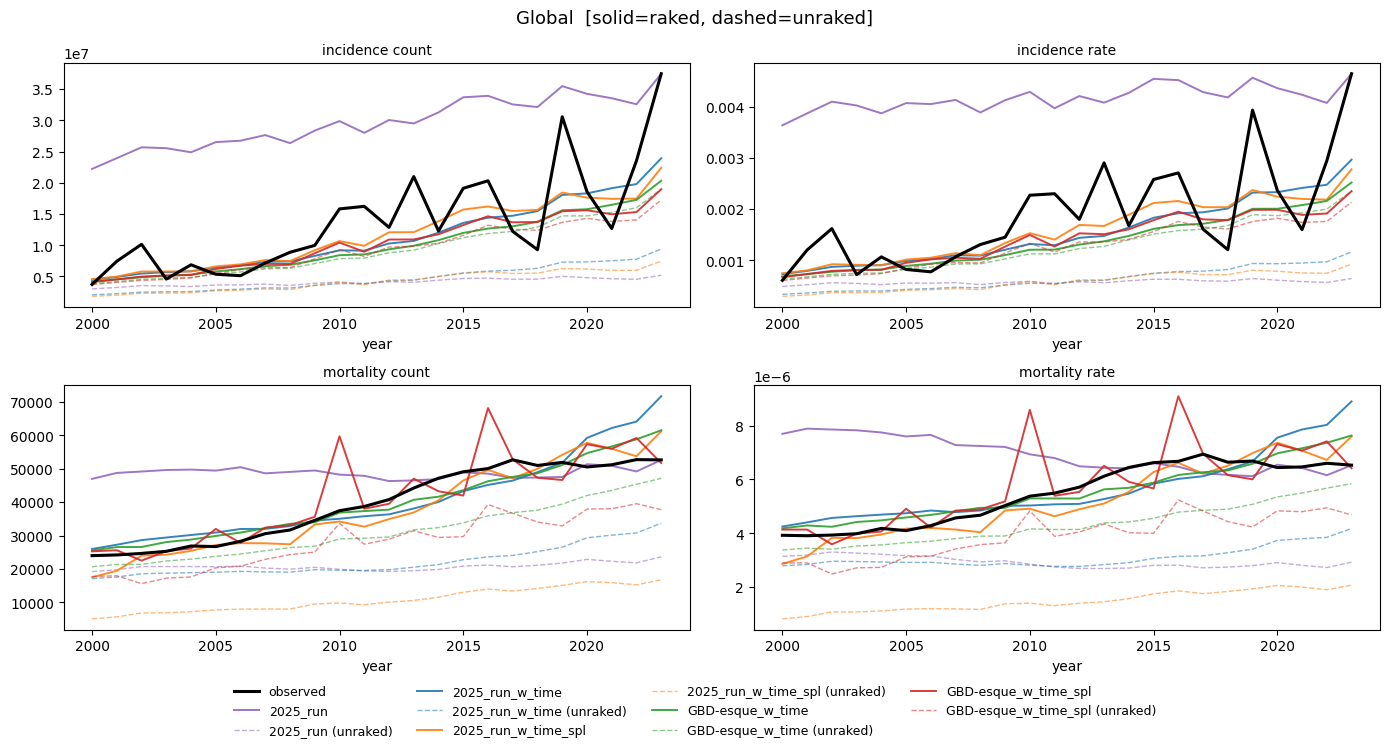

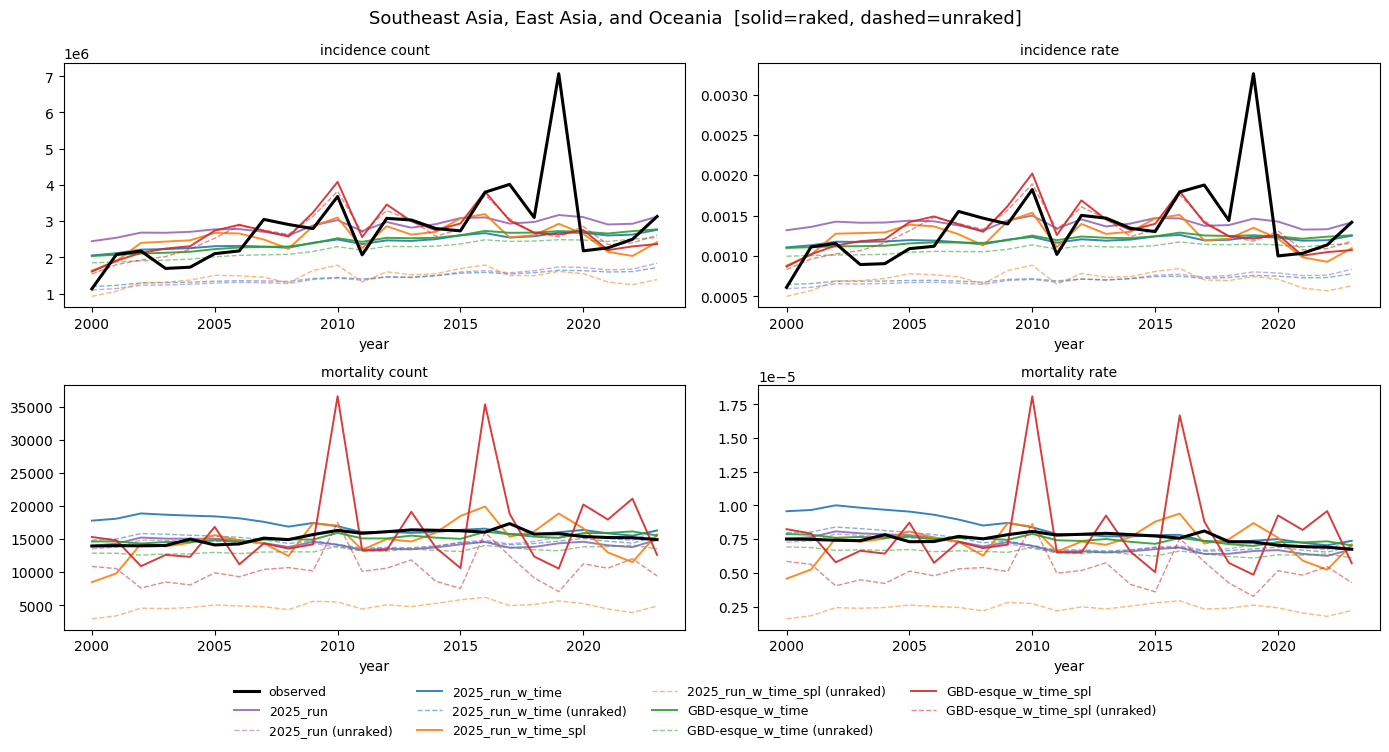

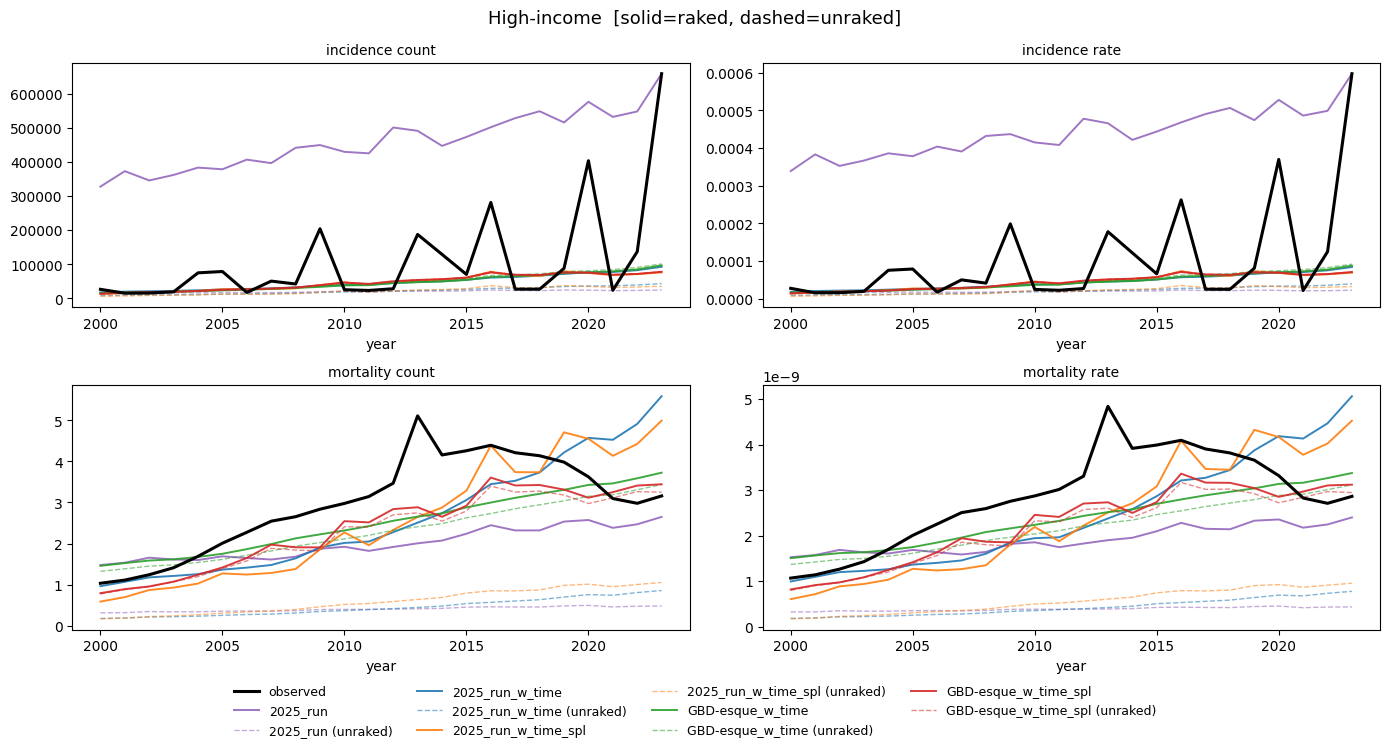

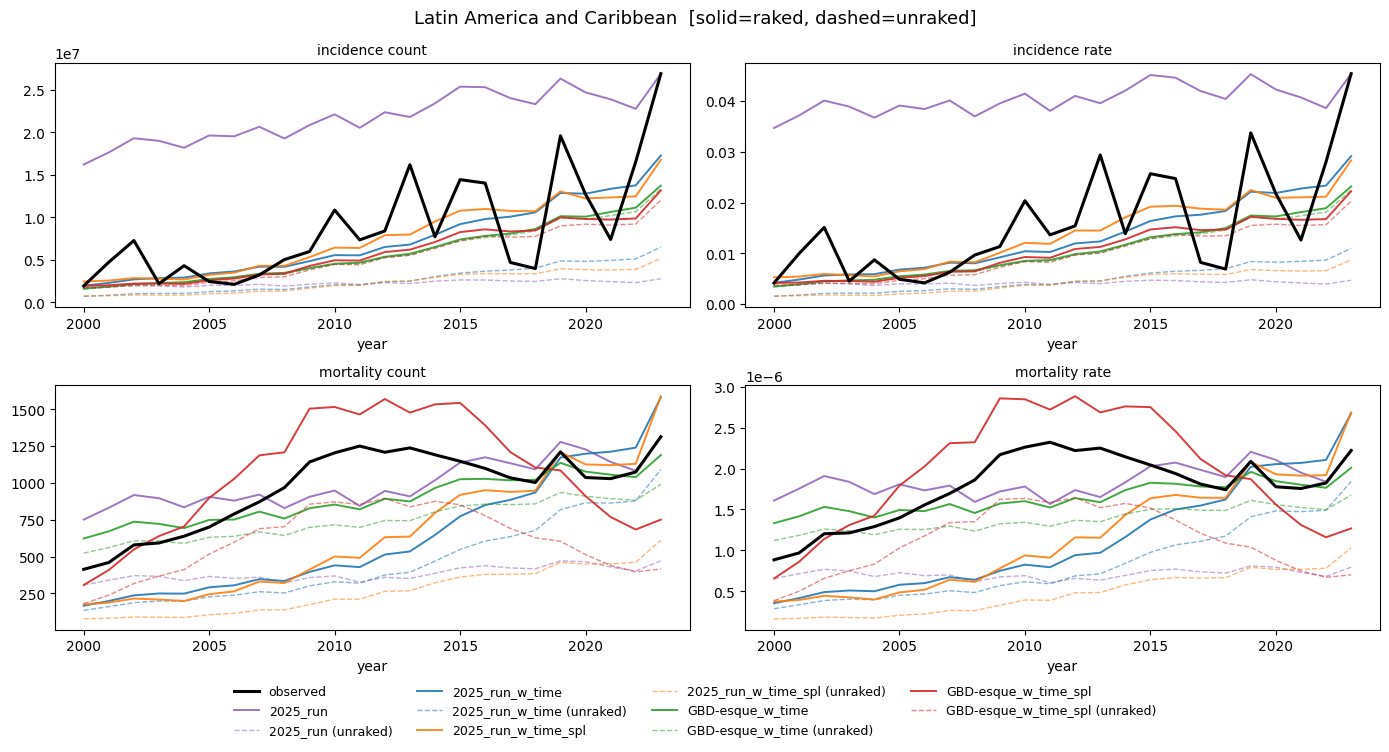

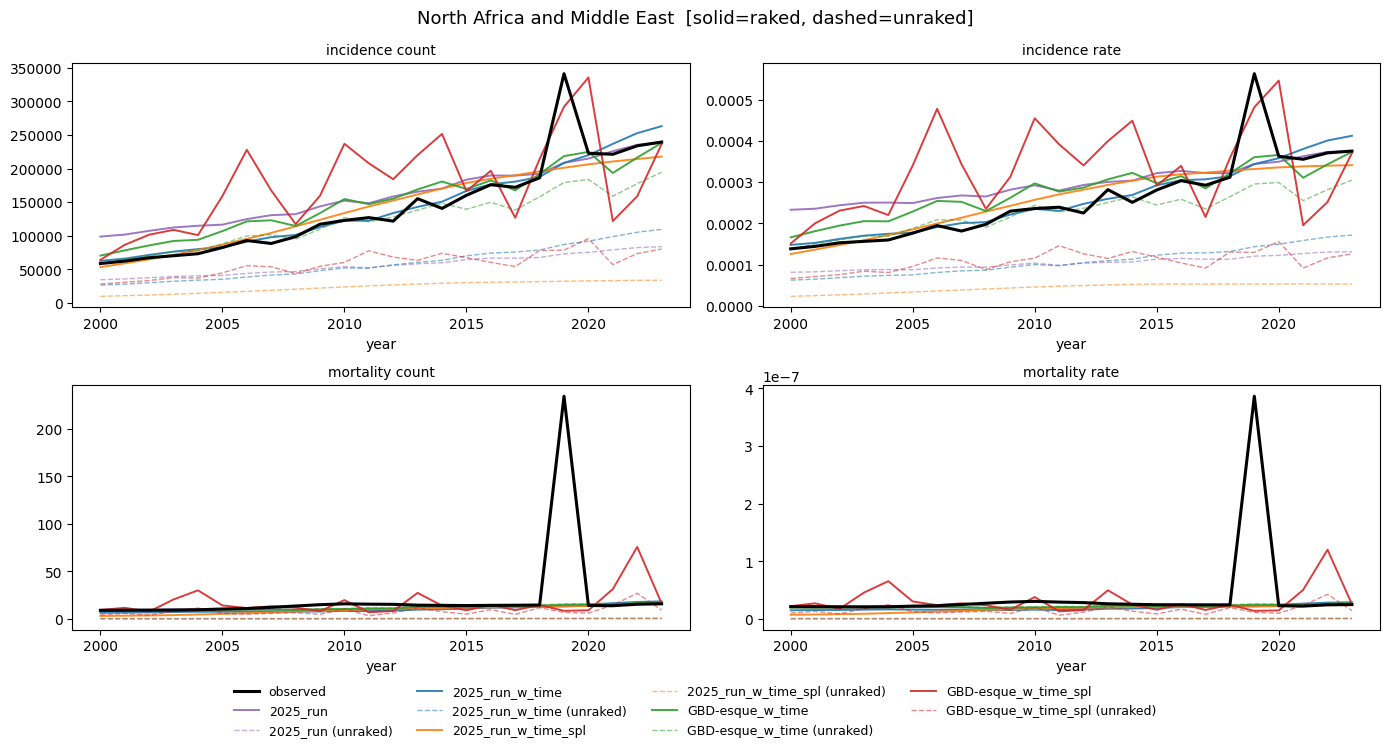

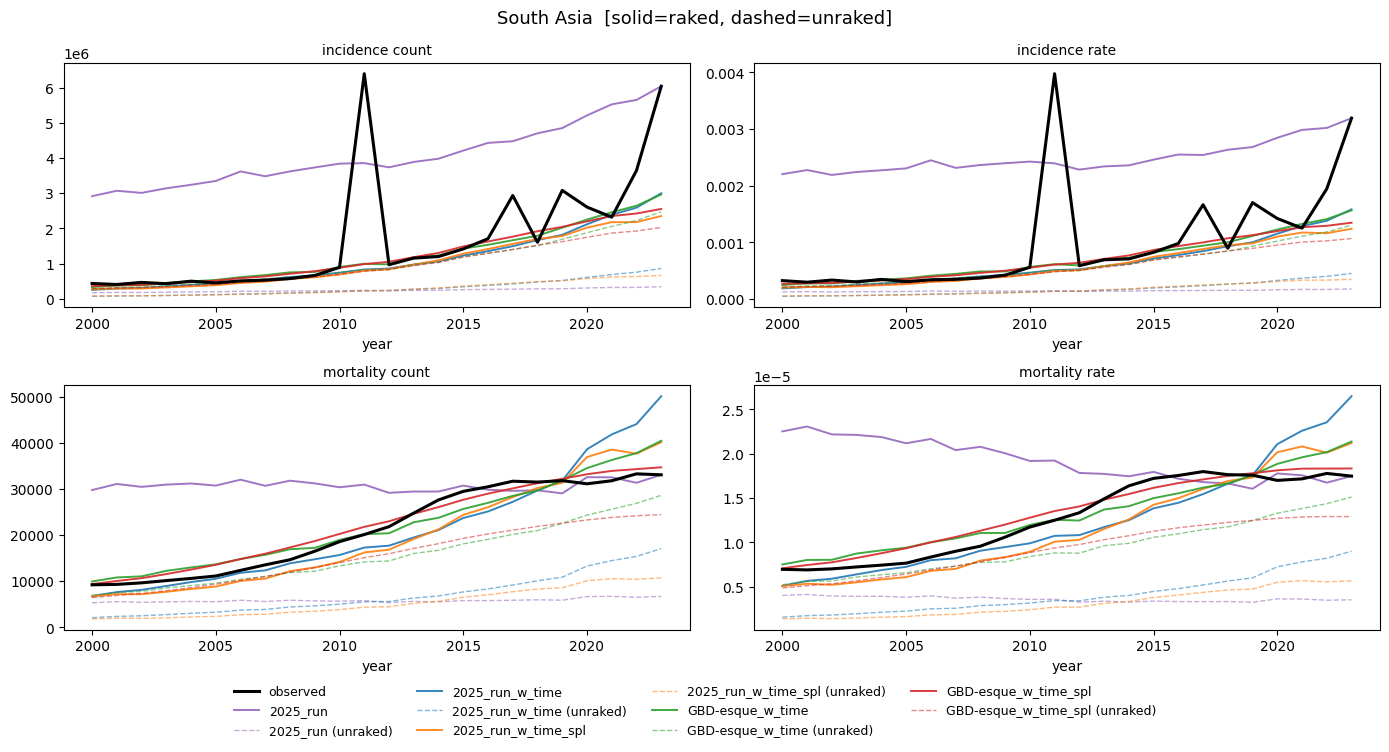

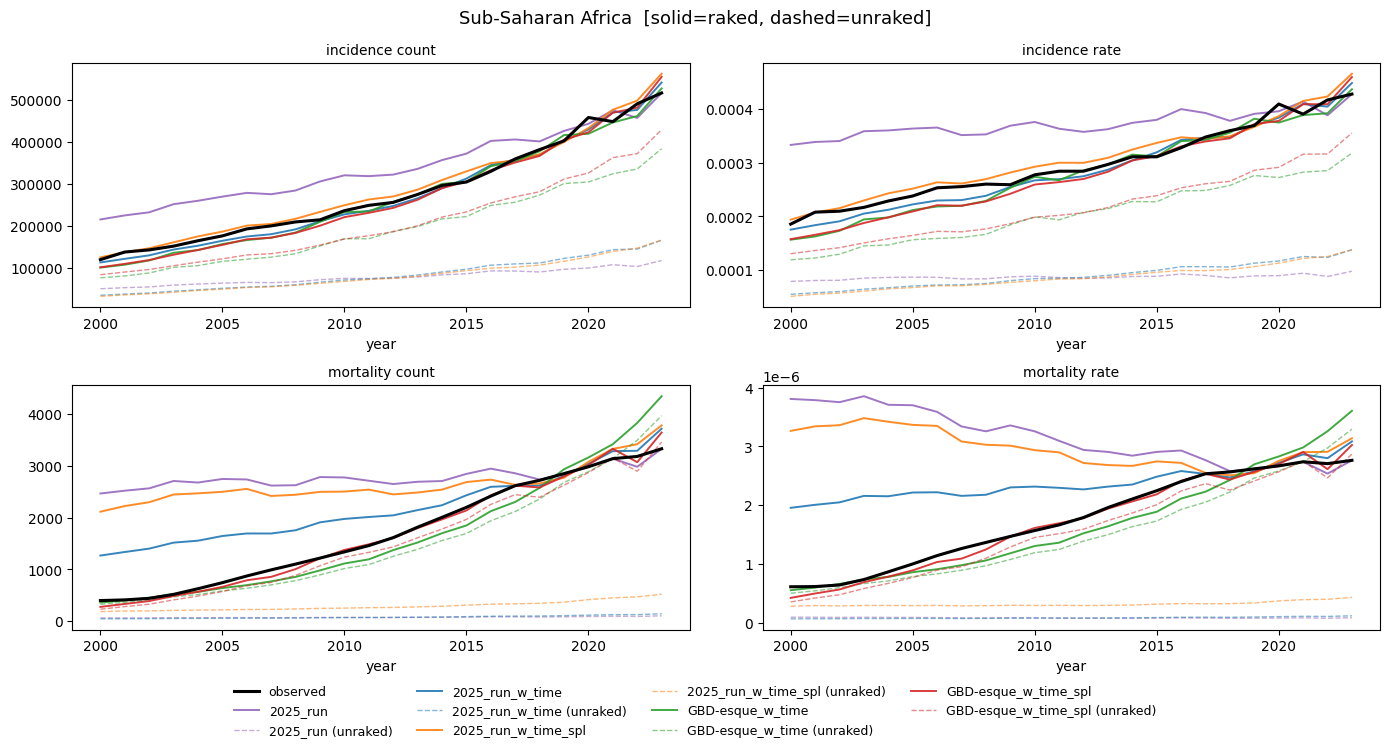

In [27]:
SHOW_UNRAKED = True     # <-- toggle: overlay the unraked lines (dotted)

STYLE = {'2025_run':       ('tab:purple', '-'),
         '2025_run_w_time':        ('tab:blue',   '-'),
         '2025_run_w_time_spl':  ('tab:orange', '-'),
         'GBD-esque_w_time':  ('tab:green',  '-'),
         'GBD-esque_w_time_spl': ('tab:red',    '-')}
PLOT_LOCS = [1, *SUPER_REGIONS]      # global + the 6 super-regions (31 never present)

FORMULATIONS_TO_PLOT = FORMULATIONS

# Observed COUNT = observed rate x that location's own population.
pop_all_age = (inputs.population[['location_id','year_id','population']]
               .drop_duplicates(['location_id','year_id']))
obs_plot = obs.merge(pop_all_age, on=['location_id','year_id'], how='left')
for meas in ('inc','mort'):
    obs_plot[f'obs_{meas}_count'] = obs_plot[f'obs_{meas}'] * obs_plot['population']

for loc in PLOT_LOCS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(f'{NAME.get(loc, loc)}'
                 + ('  [solid=raked, dashed=unraked]' if SHOW_UNRAKED else ''),
                 fontsize=13)
    o = obs_plot[obs_plot.location_id == loc].sort_values('year_id')
    for r, meas in enumerate(('inc','mort')):
        rate_col, count_col = MEASURES[meas]
        for c, (col, kind) in enumerate(((count_col,'count'), (rate_col,'rate'))):
            ax = axes[r, c]
            obs_col = f'obs_{meas}_count' if kind == 'count' else f'obs_{meas}'
            ax.plot(o.year_id, o[obs_col], 'k-', lw=2.2, label='observed', zorder=5)
            for f in FORMULATIONS_TO_PLOT:
                colour, ls = STYLE[f.id]
                p = results[('raked', f.id)]['products']
                p = p[p.location_id == loc].sort_values('year_id')
                ax.plot(p.year_id, p[col], lw=1.4, alpha=.9, color=colour, ls=ls,
                        label=f.id)
                if SHOW_UNRAKED:
                    u = results[('unraked', f.id)]['products']
                    u = u[u.location_id == loc].sort_values('year_id')
                    ax.plot(u.year_id, u[col], lw=1.0, alpha=.55, color=colour,
                            ls='--', label=f'{f.id} (unraked)')
            ax.set_title(f"{'incidence' if meas=='inc' else 'mortality'} {kind}",
                         fontsize=10)
            ax.set_xlabel('year')
    # axes[0,0].legend(fontsize=6, ncol=2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03),
               ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=(0, 0.01, 1, 1))
    plt.show()


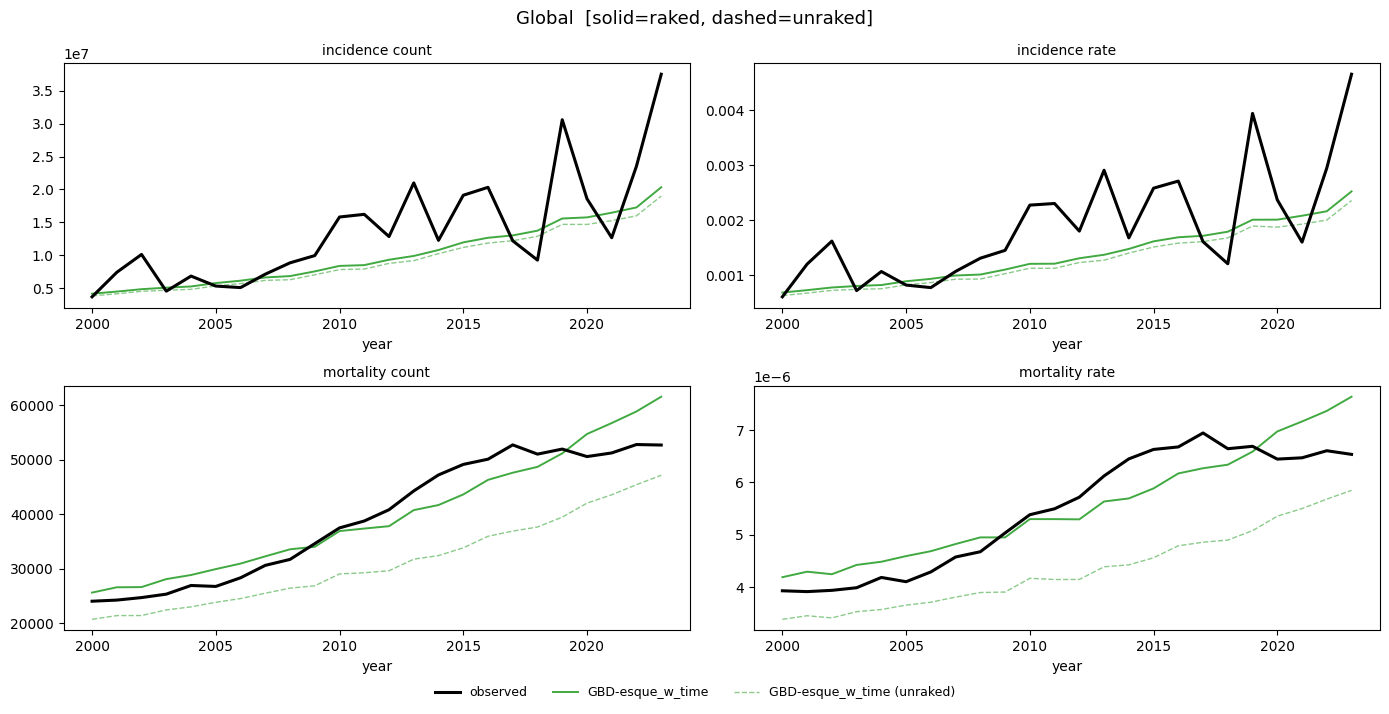

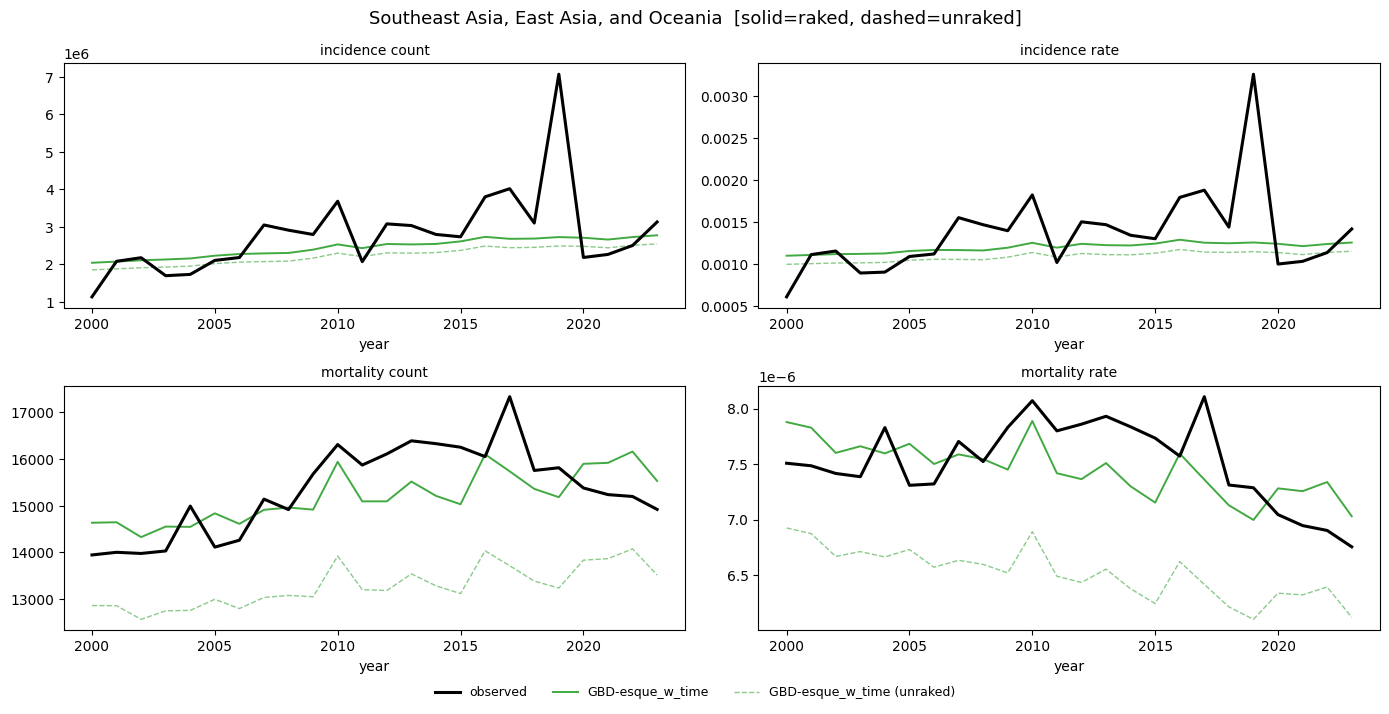

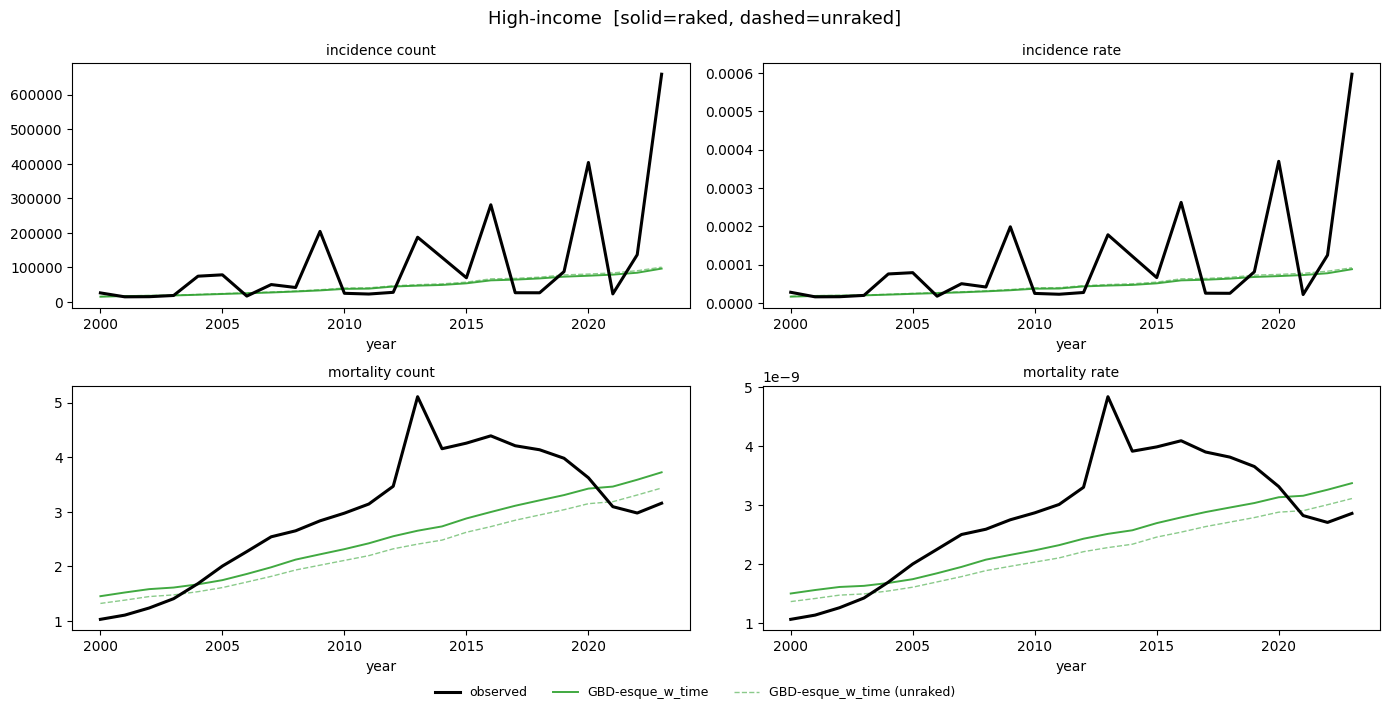

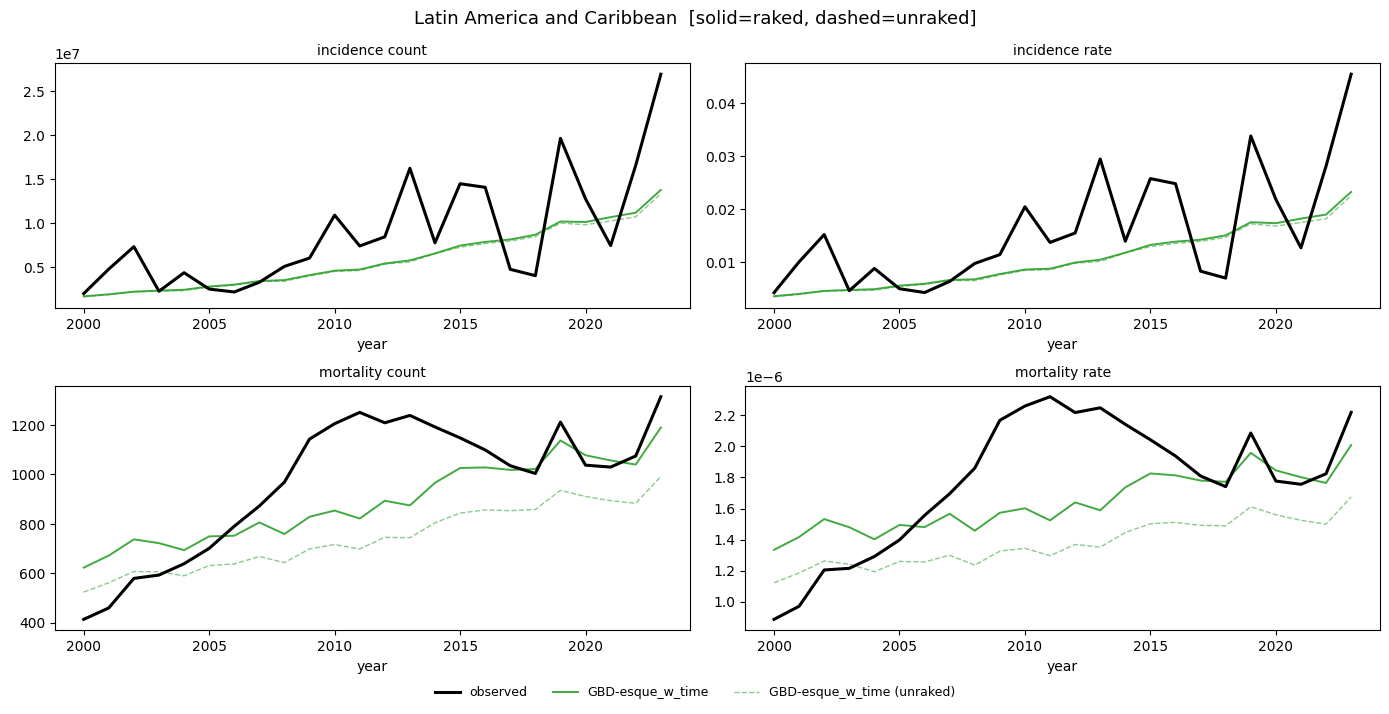

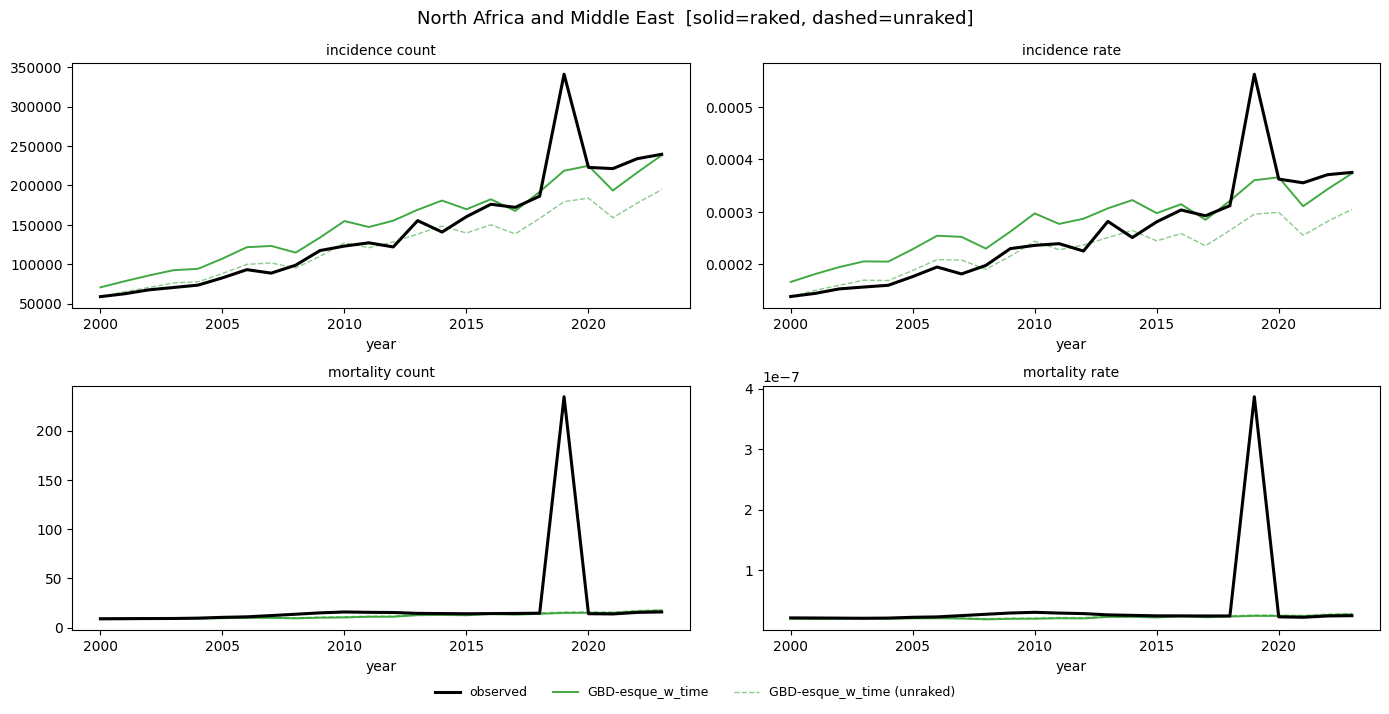

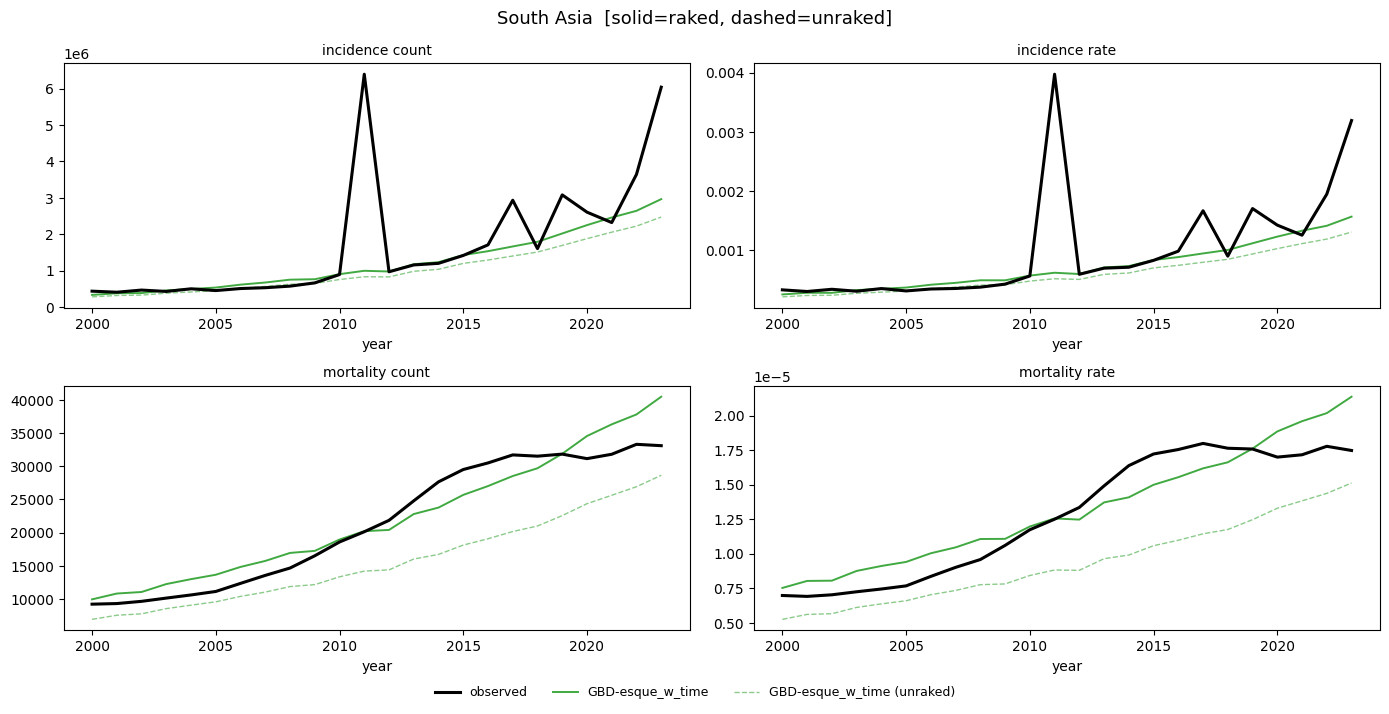

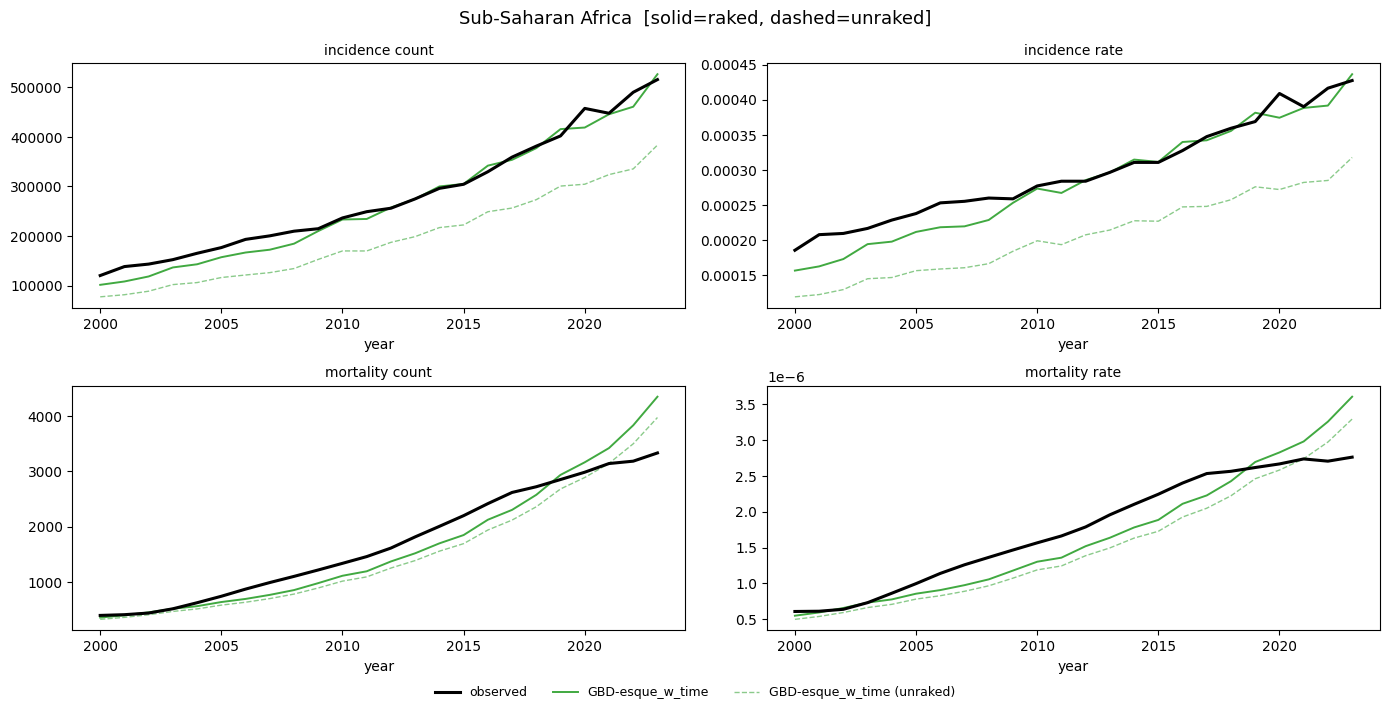

In [26]:
SHOW_UNRAKED = True     # <-- toggle: overlay the unraked lines (dotted)

STYLE = {'2025_run':       ('tab:purple', '-'),
         '2025_run_w_time':        ('tab:blue',   '-'),
         '2025_run_w_time_spl':  ('tab:orange', '-'),
         'GBD-esque_w_time':  ('tab:green',  '-'),
         'GBD-esque_w_time_spl': ('tab:red',    '-')}
PLOT_LOCS = [1, *SUPER_REGIONS]      # global + the 6 super-regions (31 never present)

FORMULATIONS_TO_PLOT = FORMULATIONS[3:4]

# Observed COUNT = observed rate x that location's own population.
pop_all_age = (inputs.population[['location_id','year_id','population']]
               .drop_duplicates(['location_id','year_id']))
obs_plot = obs.merge(pop_all_age, on=['location_id','year_id'], how='left')
for meas in ('inc','mort'):
    obs_plot[f'obs_{meas}_count'] = obs_plot[f'obs_{meas}'] * obs_plot['population']

for loc in PLOT_LOCS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(f'{NAME.get(loc, loc)}'
                 + ('  [solid=raked, dashed=unraked]' if SHOW_UNRAKED else ''),
                 fontsize=13)
    o = obs_plot[obs_plot.location_id == loc].sort_values('year_id')
    for r, meas in enumerate(('inc','mort')):
        rate_col, count_col = MEASURES[meas]
        for c, (col, kind) in enumerate(((count_col,'count'), (rate_col,'rate'))):
            ax = axes[r, c]
            obs_col = f'obs_{meas}_count' if kind == 'count' else f'obs_{meas}'
            ax.plot(o.year_id, o[obs_col], 'k-', lw=2.2, label='observed', zorder=5)
            for f in FORMULATIONS_TO_PLOT:
                colour, ls = STYLE[f.id]
                p = results[('raked', f.id)]['products']
                p = p[p.location_id == loc].sort_values('year_id')
                ax.plot(p.year_id, p[col], lw=1.4, alpha=.9, color=colour, ls=ls,
                        label=f.id)
                if SHOW_UNRAKED:
                    u = results[('unraked', f.id)]['products']
                    u = u[u.location_id == loc].sort_values('year_id')
                    ax.plot(u.year_id, u[col], lw=1.0, alpha=.55, color=colour,
                            ls='--', label=f'{f.id} (unraked)')
            ax.set_title(f"{'incidence' if meas=='inc' else 'mortality'} {kind}",
                         fontsize=10)
            ax.set_xlabel('year')
    # axes[0,0].legend(fontsize=6, ncol=2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03),
               ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=(0, 0.01, 1, 1))
    plt.show()


## 6. Partial dependence for every non-linear term

One multi-panel figure per (formulation, model).

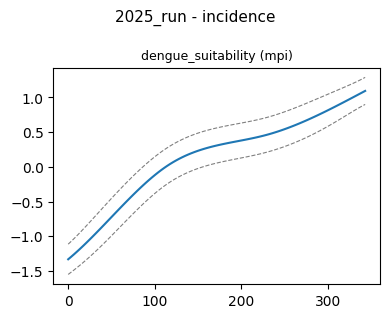

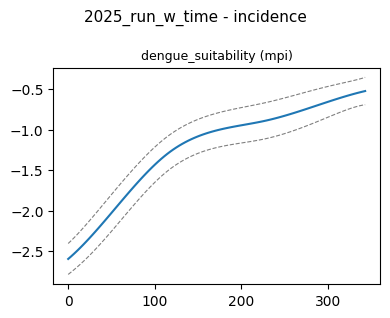

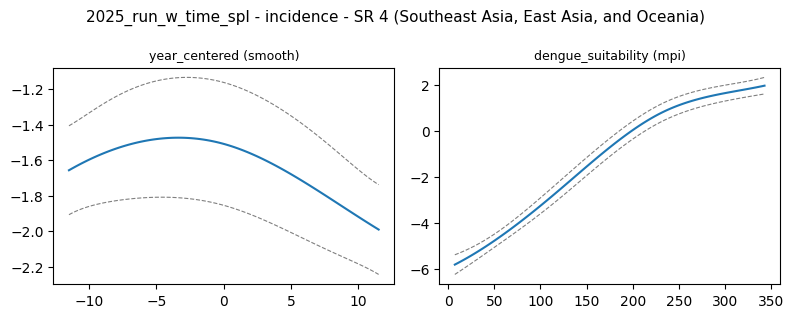

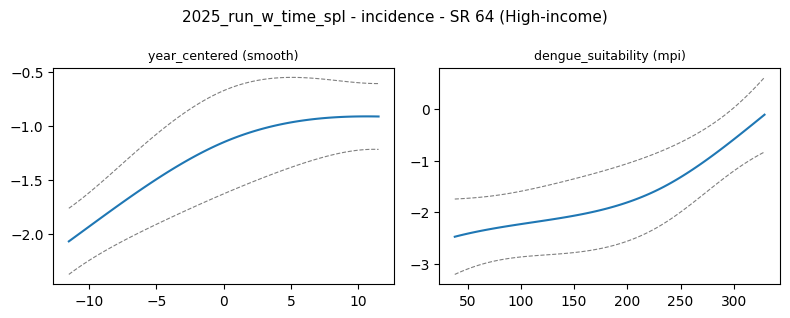

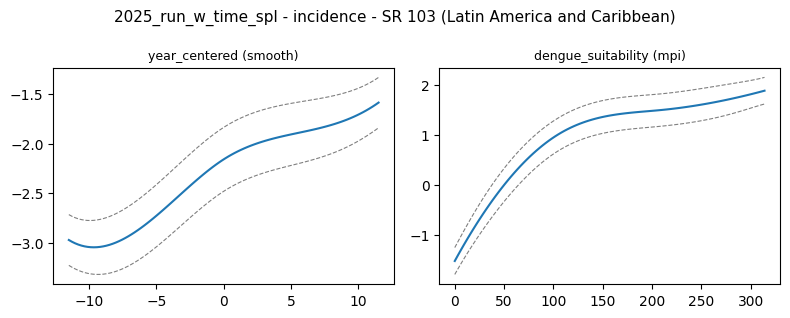

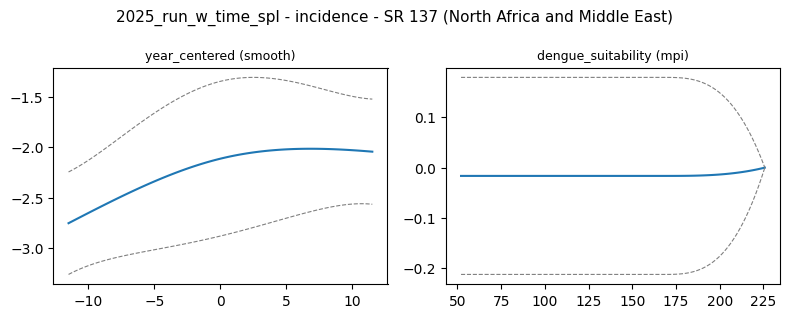

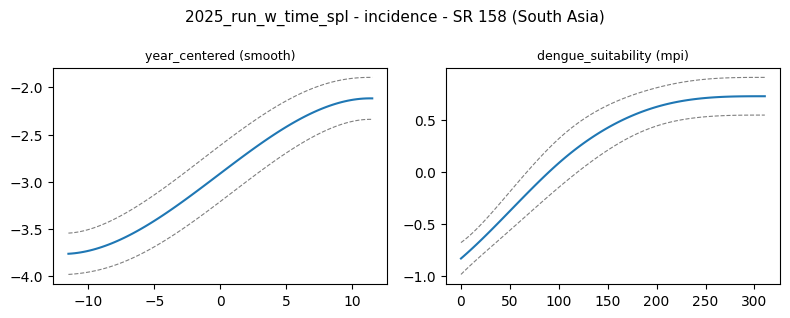

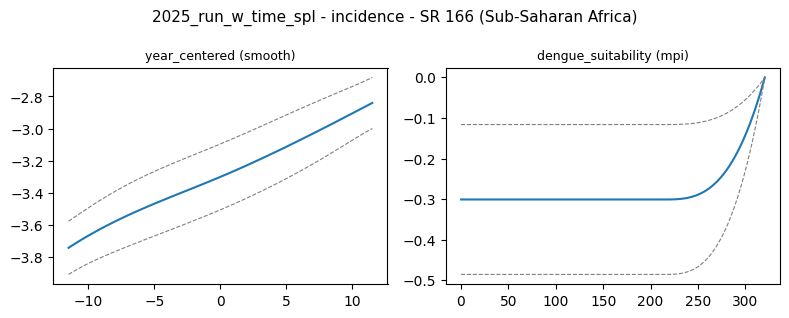

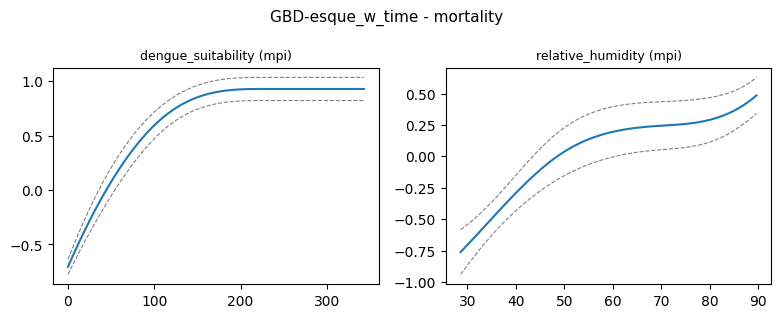

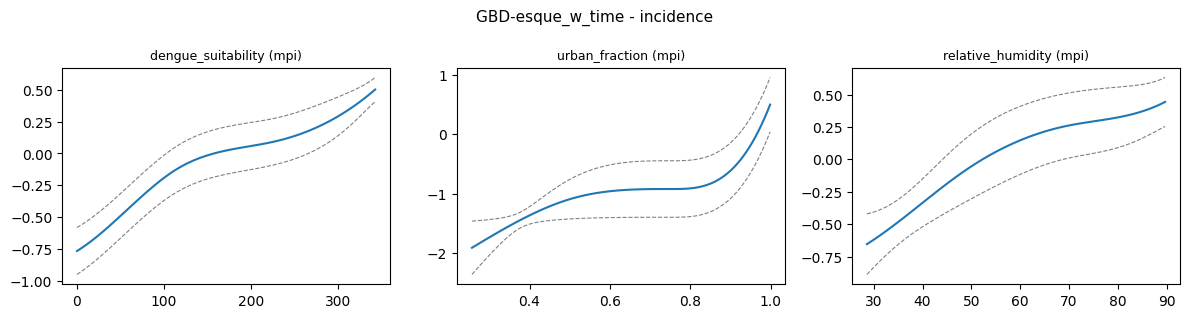

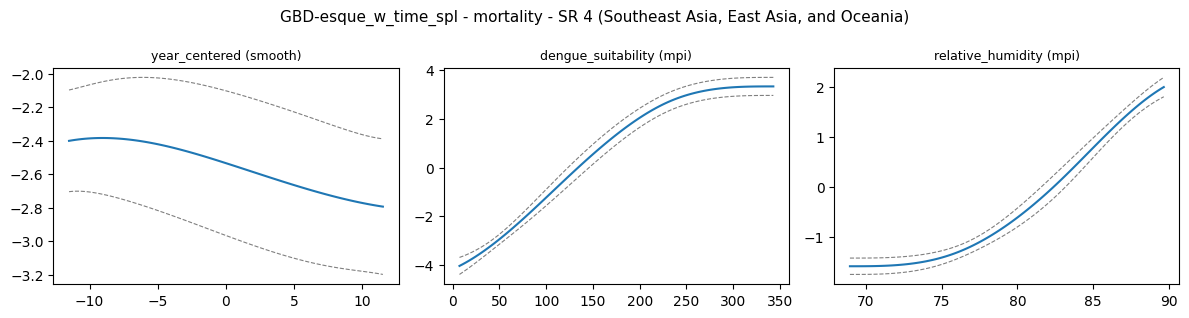

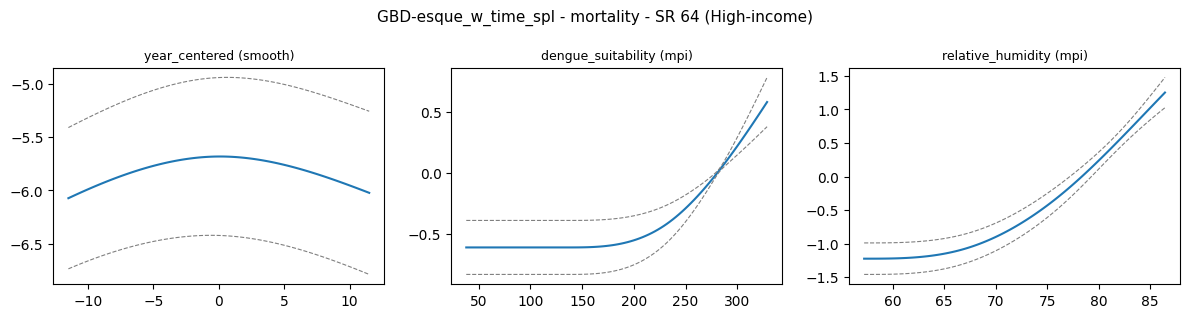

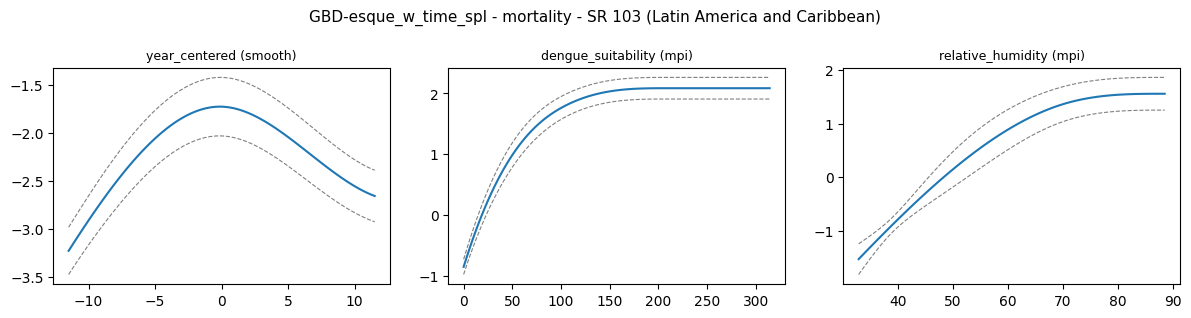

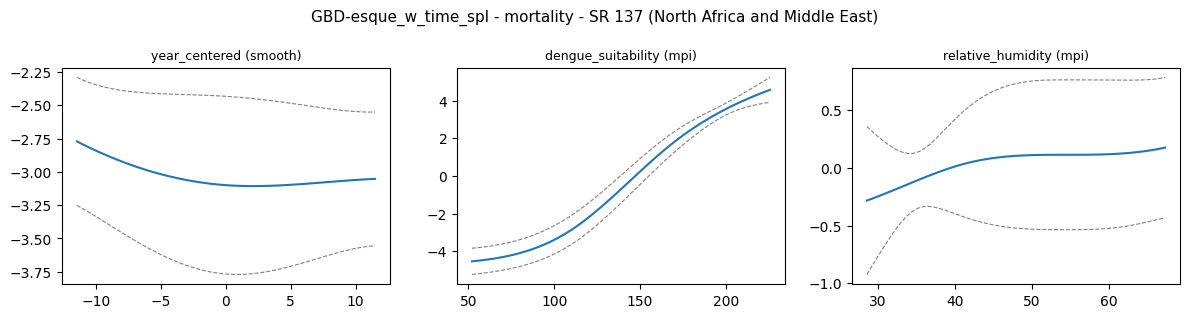

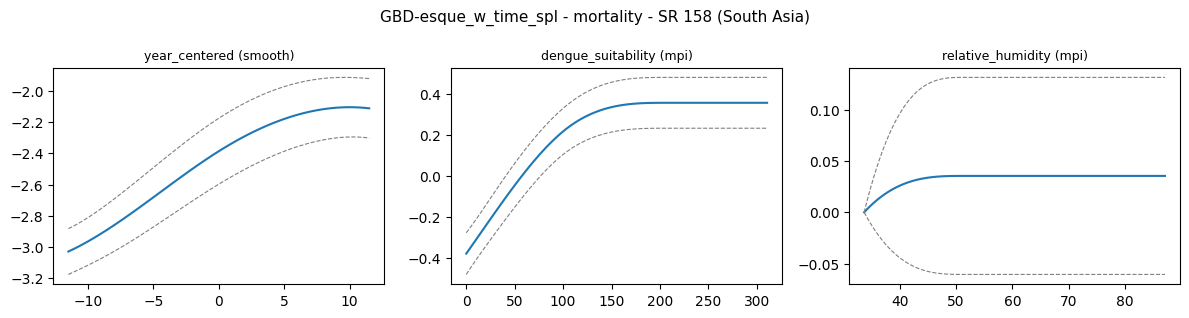

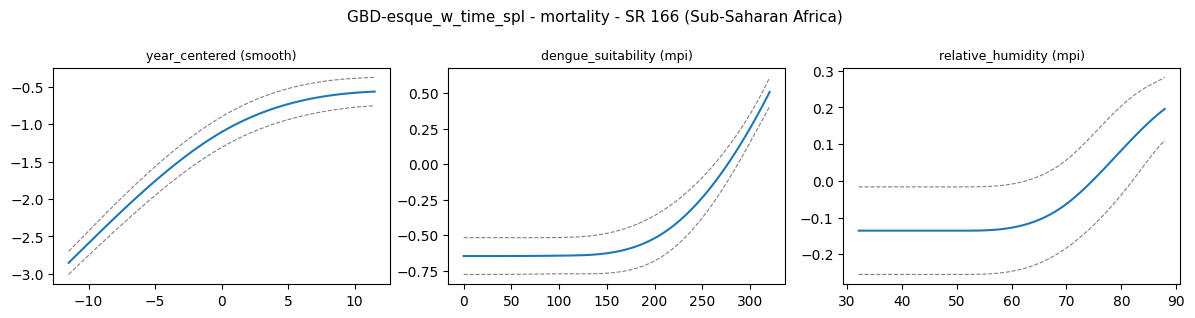

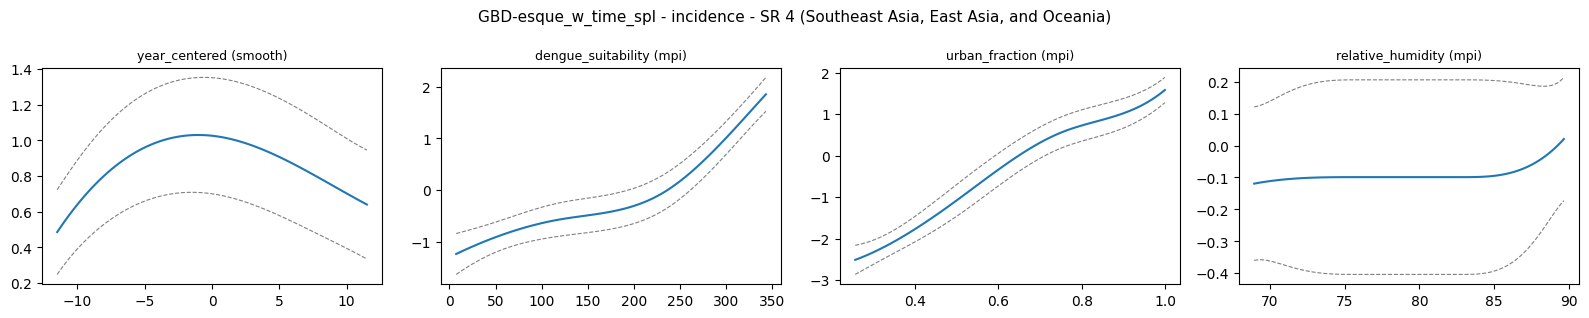

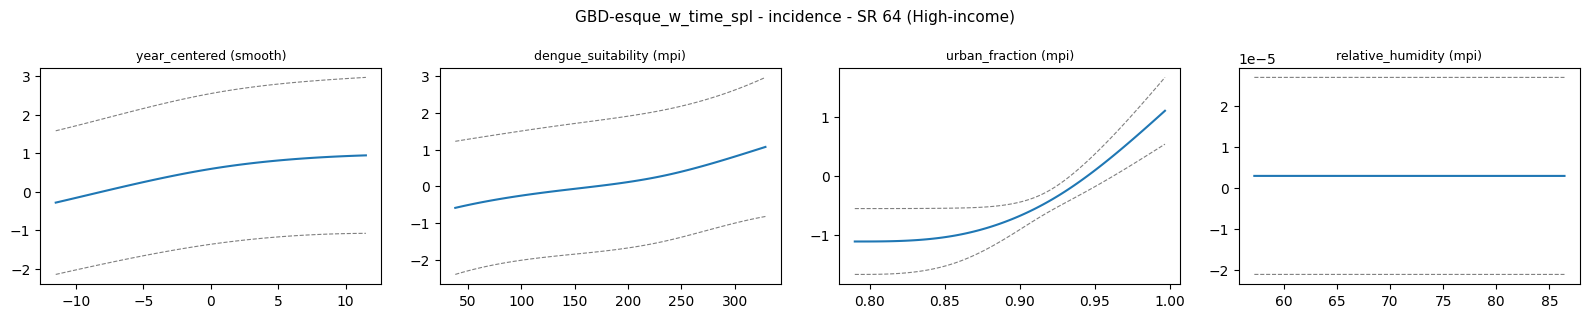

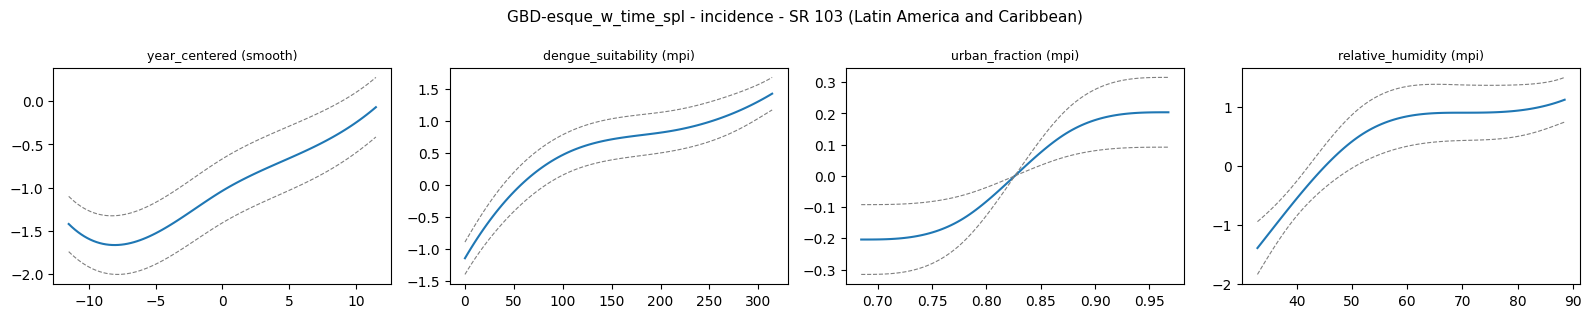

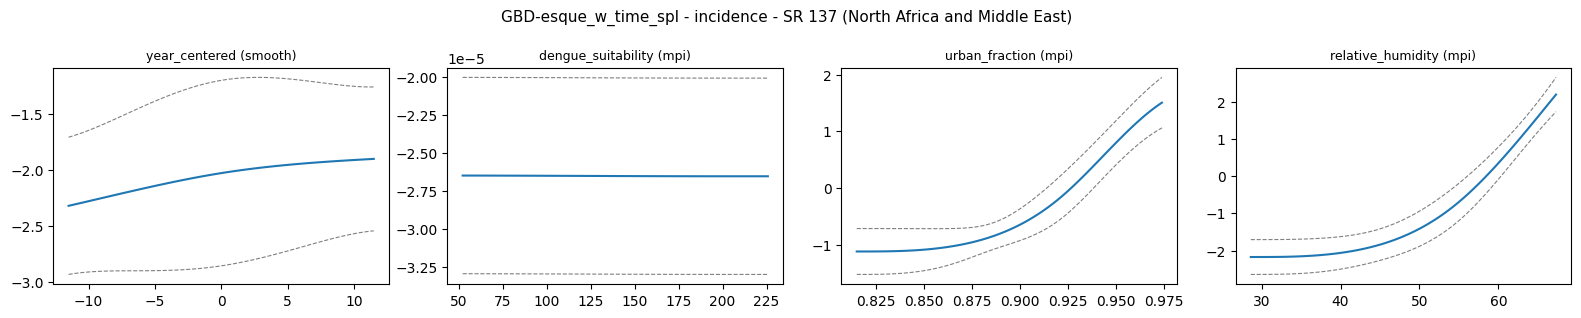

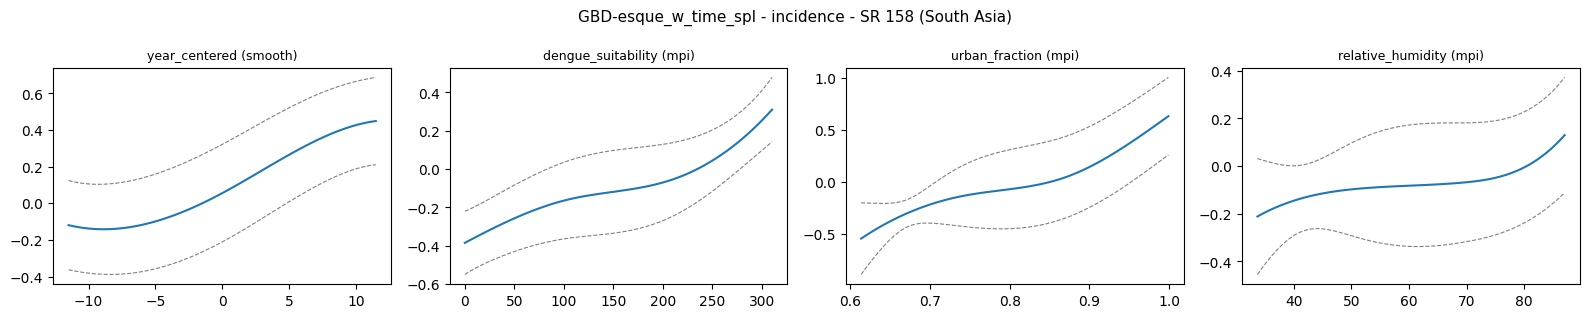

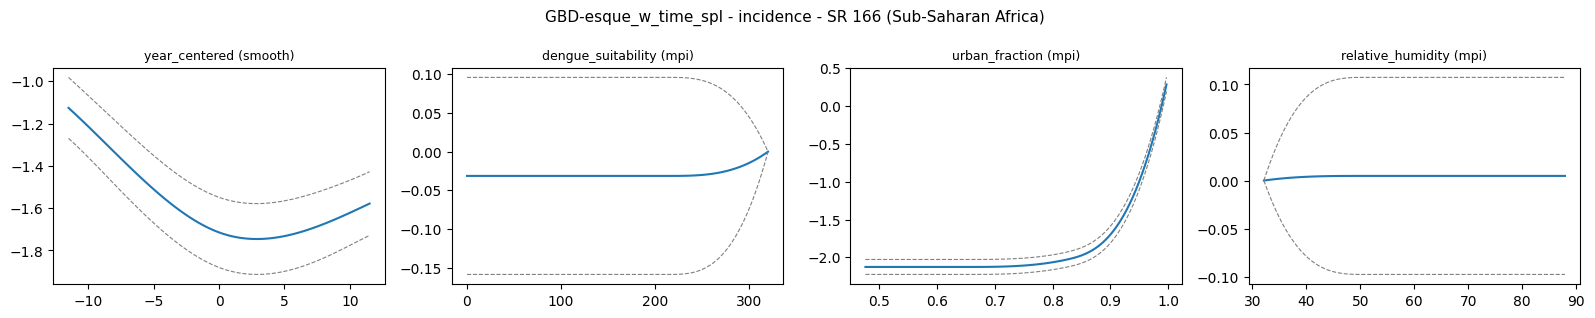

In [29]:
# Partial dependence for every non-linear term. A by_super_region formulation gets
# one row of panels per super-region, which is the point of fitting it that way.
for f in FORMULATIONS:
    run = results[('raked', f.id)]['run']
    for outcome, of in run.fits.items():
        terms = f.terms[outcome]
        nl = [(k, t) for k, t in enumerate(terms)
              if t.form in ('mpi', 'smooth', 'mpd', 'cv', 'cx')]
        if not nl:
            continue
        subs = of.model if isinstance(of.model, dict) else {None: of.model}
        for group, model in subs.items():
            fig, axes = plt.subplots(1, len(nl), figsize=(4 * len(nl), 3.2),
                                     squeeze=False)
            for ax, (k, spec_term) in zip(axes[0], nl):
                XX = model.generate_X_grid(term=k, n=100)
                # generate_X_grid zero-fills every non-target column, and a
                # per-super-region sub-model's A0_af levels do not include 0
                # (High-income is [21.5, 26.5]), so pyGAM rejects the grid as out
                # of domain. Clip each non-target column into its own fitted range.
                target_feature = model.terms[k].feature
                for gam_term in model.terms:
                    if getattr(gam_term, 'isintercept', False):
                        continue
                    if gam_term.feature == target_feature:
                        continue
                    lo, hi = gam_term.edge_knots_
                    XX[:, gam_term.feature] = np.clip(XX[:, gam_term.feature], lo, hi)

                pdep, ci = model.partial_dependence(term=k, X=XX, width=.95)
                ax.plot(XX[:, target_feature], pdep)
                ax.plot(XX[:, target_feature], ci, ls='--', c='grey', lw=.8)
                ax.set_title(f'{spec_term.col} ({spec_term.form})', fontsize=9)

            tag = '' if group is None else f' - SR {group} ({NAME.get(group, group)})'
            fig.suptitle(f'{f.id} - {outcome}{tag}', fontsize=11)
            plt.tight_layout()
            plt.show()


## 7. Model summaries

pyGAM's own summary: edf, lambda and approximate p-values per term. pyGAM warns
in its own documentation that these p-values are unreliable, especially after
any term selection -- read them as indicative, not inferential. There is no
classical per-coefficient standard error available from this engine.

In [ ]:
# Named summary: real covariate names, coefficients and standard errors for the
# linear terms. Spline and factor terms have no single interpretable coefficient --
# read their shape off the partial-dependence panels; what is reported for them is
# effective dof and the term p-value. pyGAM's p-values are approximate and it warns
# they are unreliable when a feature carries both a spline and a linear term.
#
# A by_super_region formulation holds one model PER super-region, so it prints one
# table per group.
from idd_forecast_mbp.lib.modeling.gam_summary import summarize_gam

def _fmt(v):
    return f'{v:.4g}'

for f in FORMULATIONS:
    run = results[('raked', f.id)]['run']
    for outcome, of in run.fits.items():
        subs = of.model if isinstance(of.model, dict) else {None: of.model}
        for group, model in subs.items():
            tag = '' if group is None else f'  |  SR {group} ({NAME.get(group, group)})'
            print('=' * 88)
            print(f'{f.id}  |  {outcome}  |  grain={f.grain_for(outcome)}'
                  f'  |  n_fit={of.n_fit_rows:,}{tag}')
            print('=' * 88)
            tbl = summarize_gam(model, f.terms[outcome])
            print(tbl.to_string(index=False, na_rep='', float_format=_fmt))
            print()


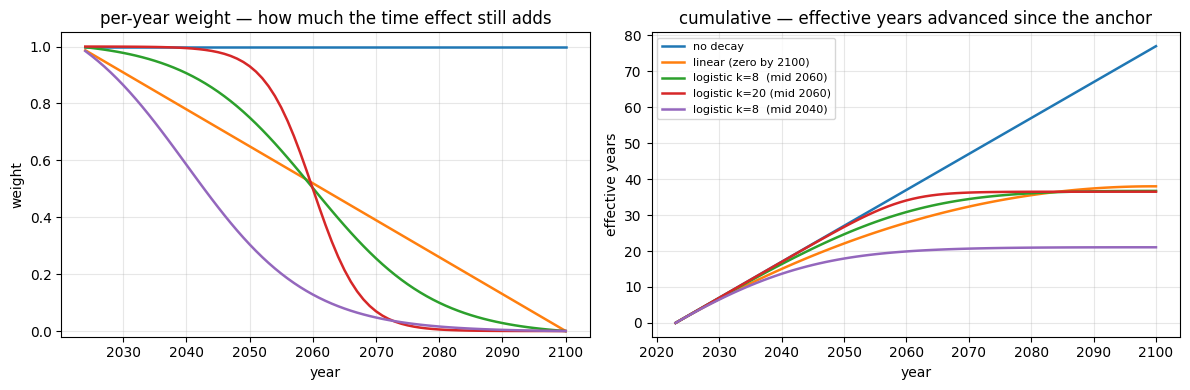

  no decay                     advance  77.0 yr
  linear (zero by 2100)        advance  38.0 yr
  logistic k=8  (mid 2060)     advance  36.7 yr
  logistic k=20 (mid 2060)     advance  36.5 yr
  logistic k=8  (mid 2040)     advance  21.0 yr


In [30]:
# What each decay does to the time effect. Nothing is fitted here — a decay only
# reshapes the year covariate you predict on, so the fitted coefficient never moves.
from idd_forecast_mbp.lib.modeling.year_path import effective_year

YEARS = np.arange(ANCHOR_YEAR, 2101)
DECAYS = {
    'no decay':                 ('identity',       {}),
    'linear (zero by 2100)':    ('linear_decay',   {}),
    'logistic k=8  (mid 2060)': ('logistic_decay', {'midpoint_year': 2060, 'steepness': 8.0}),
    'logistic k=20 (mid 2060)': ('logistic_decay', {'midpoint_year': 2060, 'steepness': 20.0}),
    'logistic k=8  (mid 2040)': ('logistic_decay', {'midpoint_year': 2040, 'steepness': 8.0}),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, (path, kw) in DECAYS.items():
    g = effective_year(YEARS, ANCHOR_YEAR, path, **kw)
    axes[0].plot(YEARS[1:], np.diff(g), lw=1.8, label=label)
    axes[1].plot(YEARS, g - ANCHOR_YEAR, lw=1.8, label=label)
axes[0].set_title('per-year weight — how much the time effect still adds')
axes[0].set_ylabel('weight'); axes[0].set_ylim(-0.02, 1.05)
axes[1].set_title('cumulative — effective years advanced since the anchor')
axes[1].set_ylabel('effective years')
for ax in axes:
    ax.set_xlabel('year'); ax.grid(alpha=.3)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for label, (path, kw) in DECAYS.items():
    g = effective_year(YEARS, ANCHOR_YEAR, path, **kw)
    print(f'  {label:28s} advance {g[-1] - ANCHOR_YEAR:5.1f} yr')
